In [15]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import genextreme as gev

from unseen import eva
from unseen import stability

import utils

In [16]:
# optional parameters
# (this cell is tagged "parameters")

metric = 'txx'
location = [3, 2]
model_dict = {
    'BCC-CSM2-MR': 'tab:blue',
#    'CAFE': 'tab:orange',
    'CMCC-CM2-SR5': 'tab:green',
    'CanESM5': 'tab:red',
    'EC-Earth3': 'tab:purple',
    'IPSL-CM6A-LR': 'tab:brown',
    'MIROC6': 'tab:pink',
    'MPI-ESM1-2-HR': 'tab:grey',
    'MRI-ESM2-0': 'tab:olive',
    'NorCPM1': 'tab:cyan',
}  

In [17]:
assert "location" in locals(), "Must provide a location name"
assert "metric" in locals(), "Must provide a metric (rx1day or txx)"
assert "model_dict" in locals(), "Must provide a model dict"

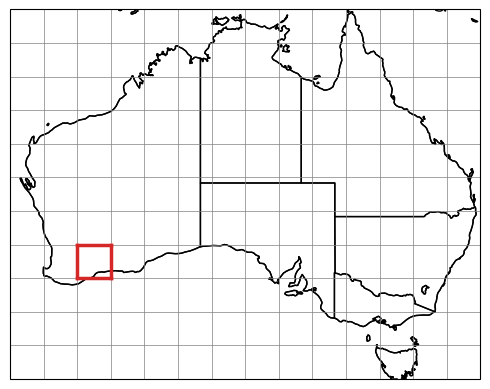

In [18]:
if type(location) == list:
    lat_index, lon_index = location
    utils.plot_grid_box(lat_index, lon_index)

In [35]:
def get_return_values(metric, location, model_dict):
    """Get return values for each dataset."""
    
    return_values_dict = {}
    gev_dict = {}
    size_dict = {}

    da_obs = utils.get_obs_data(metric, location)
    da_obs_detrended, linear_data_obs = utils.detrend_obs(da_obs)
    for model in model_dict:
        print(model)
        da_model_stacked = utils.get_model_data(metric, model, location)
        da_model_detrended, da_model_detrended_stacked, linear_data_model = utils.detrend_model(da_model_stacked)
        da_model_detrended_stacked_bc_mean = utils.mean_correction(da_model_detrended, da_obs_detrended, metric)
        gev_model_detrended_bc_mean = list(eva.fit_gev(da_model_detrended_stacked_bc_mean.values))
        return_periods, return_values_model_bc_mean = stability.return_curve(
            da_model_detrended_stacked_bc_mean,
            'gev',
            params=gev_model_detrended_bc_mean,
        )
        return_values_dict[model] = return_values_model_bc_mean
        gev_dict[model] = gev_model_detrended_bc_mean
        size_dict[model] = len(da_model_detrended_stacked_bc_mean)

    return_values_df = pd.DataFrame(return_values_dict)
    return_values_df.index = return_periods
    return_values_df = return_values_df.drop([1.0])
    
    return return_values_df, gev_dict, size_dict

In [36]:
return_df, gev_dict, size_dict = get_return_values(metric, location, model_dict)

BCC-CSM2-MR
CMCC-CM2-SR5
CanESM5
EC-Earth3
IPSL-CM6A-LR
MIROC6
MPI-ESM1-2-HR
MRI-ESM2-0
NorCPM1


In [37]:
size_dict

{'BCC-CSM2-MR': 3888,
 'CMCC-CM2-SR5': 10800,
 'CanESM5': 10260,
 'EC-Earth3': 7830,
 'IPSL-CM6A-LR': 5130,
 'MIROC6': 5310,
 'MPI-ESM1-2-HR': 5310,
 'MRI-ESM2-0': 2400,
 'NorCPM1': 10620}

In [45]:
def get_uncertainty(gev_dict, size_dict):
    """Get (parametric) uncertainty."""

    bootstrap_samples_dict = {}
    n_bootstraps = 100
    model_number = 0
    for model, original_gev_params in gev_dict.items():
        print(model)
        shape, loc, scale = original_gev_params
        sample_size = size_dict[model]
        start = model_number * n_bootstraps
        for i in range(n_bootstraps):
            boot_data = gev.rvs(shape, loc=loc, scale=scale, size=sample_size)
            boot_gev_params = list(eva.fit_gev(boot_data))
            return_periods, return_values = stability.return_curve(boot_data, 'gev', params=boot_gev_params)
            bootstrap_samples_dict[start + i] = return_values
        model_number = model_number + 1
    df = pd.DataFrame(bootstrap_samples_dict)
    df.index = return_periods
    df = df.drop([1.0])

    return df

In [46]:
uncertainty_df = get_uncertainty(gev_dict, size_dict)

BCC-CSM2-MR
CMCC-CM2-SR5
CanESM5
EC-Earth3
IPSL-CM6A-LR
MIROC6
MPI-ESM1-2-HR
MRI-ESM2-0
NorCPM1


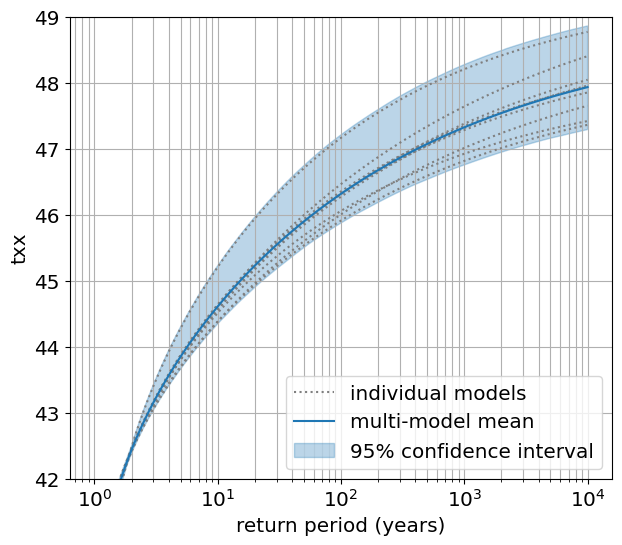

In [75]:
plot_practical_uncertainty(return_df, uncertainty_df, ylim=[42, 49])

In [74]:
def plot_practical_uncertainty(return_df, uncertainty_df, ylim=None, legend_offset=1.7):
    """Plot practical uncertainty"""

    return_periods = return_df.index.values
    ds_mean = return_df.mean(axis=1)
    ds_lower = uncertainty_df.quantile(q=0.025, axis=1)
    ds_upper = uncertainty_df.quantile(q=0.975, axis=1)
    nmodels = return_df.shape[-1]
    
    fig = plt.figure(figsize=[7, 6])
    ax = fig.add_subplot(111)
    for i in range(nmodels):
        model_ds = return_df.iloc[:, i]
        label = 'individual models' if i == 0 else None
        ax.plot(return_periods, model_ds.values, label=label, color='tab:gray', linestyle=':')
    ax.plot(return_periods, ds_mean.values, label='multi-model mean', color='tab:blue')
    #ax.plot(return_periods, ds_upper.values, label='95% confidence interval', color='black', linestyle=':')
    #ax.plot(return_periods, ds_lower.values, color='black', linestyle=':')
    ax.fill_between(
        return_periods, ds_lower.values, ds_upper.values, label='95% confidence interval', color='tab:blue', alpha=0.3
    )
    
#    ax.legend(bbox_to_anchor=(legend_offset, 0.5), loc='center right')
    ax.legend()
    ax.set_xscale('log')
    ax.set_xlabel('return period (years)')
    ax.set_ylabel(f'{metric}')
#    ax.set_title('Return periods corresponding to GEV fits')
    if ylim:
        ax.set_ylim(ylim)
    ax.grid(which='both')
#    if outfile:
#        plt.savefig(outfile, bbox_inches='tight', facecolor='white')
    plt.show()